# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
Bahrain Import

## Selected Problem Statement: 
Approach: Direct Import Feasibility for Local Business
Problem Statement: A local business currently relies on costly third-party distributors to source [Commodity/Product], inflating operational costs and limiting margins. The procurement team needs to analyze the last five years of import data (2021-2025) to identify historical volume trends, seasonal fluctuations, and the most cost-effective countries of origin. Finding these historical patterns will allow the business to build a direct-import strategy to bypass middlemen and reduce overall procurement costs.

## 1. Introduction & Objectives
*(Guidelines: Introduce your topic and give a brief high-level overview of the industry or topic you are exploring so a non-technical audience understands the context.)*

### 1.1 Context & Background
Bahrain is a small, trade-dependent Gulf economy that imports the majority of its consumer 
goods, including textiles. The Bahrain Open Data Portal publishes monthly, transaction-level 
records of the Kingdom's imports, capturing partner country, commodity type, transaction 
value, weight, and quantity from 2021 to 2025. Knitted T-Shirts and Other Vests of Cotton is 
one of the highest-volume commodities in this dataset, sourced from over 130 different 
countries, making it a strong candidate for comparing import costs across suppliers.
### 1.2 Core Analytical Objectives
*(List the key targeted questions that will guide your analysis to solve the chosen problem statement. Use bullet points.)*
- What is the historical trend in import volume for Knitted T-Shirts from 2021 to 2025?
- Are there seasonal patterns in when this commodity is imported into Bahrain?
- Which countries of origin offer the lowest cost per kilogram for this commodity?
- Which countries should a local business prioritize for a direct-import strategy?

---

## 2. Environment Setup & Data Collection
*(Rubric Checkpoint: Ensure all modules are imported cleanly with appropriate standard aliases. Data files must be loaded using relative paths for replicability.)*

In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load data using strictly relative file paths
bh_imp_21 = pd.read_csv('../Data/bahrain_import_2021.csv')
bh_imp_22 = pd.read_csv('../Data/bahrain_import_2022.csv')
bh_imp_23 = pd.read_csv('../Data/bahrain_import_2023.csv')
bh_imp_24 = pd.read_csv('../Data/bahrain_import_2024.csv')
bh_imp_25 = pd.read_csv('../Data/bahrain_import_2025.csv')

In [11]:
#Printing csv's of 2021-2025 columns
print ('2021:' , bh_imp_21.columns.tolist())
print ('2022:' , bh_imp_22.columns.tolist())
print ('2023:' , bh_imp_23.columns.tolist())
print ('2024:' , bh_imp_24.columns.tolist())
print ('2025:' , bh_imp_25.columns.tolist())

2021: ['N', 'Year', 'Month', 'Commodity No', 'Commodity ', 'السلعة', 'UN code ', 'Country Name', 'الدولة', 'Import Value (BD)', 'Import Value (USA $)', 'Import Weight (KG)', 'Import Quantity', 'UM']
2022: ['N', 'Year', 'Month', 'Commodity No', 'Commodity ', 'السلعة', 'UN code ', 'Country Name', 'الدولة', 'Import Value (BD)', 'Import Value (USA $)', 'Import Weight (KG)', 'Import Quantity', 'UM']
2023: ['Year', 'Month', 'Commodity No', 'Commodity ', 'السلعة', 'UN code ', 'Country Name', 'Import Value (BD)', 'Import Value (USA $)', 'Import Weight (KG)', 'Import Quantity', 'UM']
2024: ['N', 'Month', 'Commodity No', 'Commodity', 'UN code', 'Country Name', 'قيمة الواردات (دينار بحريني)', 'قيمة الواردات (دولار أمريكي)', 'وزن الواردات (كجم)', 'كمية الواردات', 'وحدة القياس']
2025: ['\ufeffN', 'Year', 'Month', 'Commodity No', 'Commodity', 'السلعة', 'UN code', 'Country Name', 'الدولة', 'Import Value (BD)', 'Import Value (USA $)', 'Import Weight (KG)', 'Import Quantity', 'UM']


In [12]:
bh_imp_21.columns

Index(['N', 'Year', 'Month', 'Commodity No', 'Commodity ', 'السلعة',
       'UN code ', 'Country Name', 'الدولة', 'Import Value (BD)',
       'Import Value (USA $)', 'Import Weight (KG)', 'Import Quantity', 'UM'],
      dtype='str')

In [11]:
bh_imp_22.columns

Index(['N', 'Year', 'Month', 'Commodity No', 'Commodity ', 'السلعة',
       'UN code ', 'Country Name', 'الدولة', 'Import Value (BD)',
       'Import Value (USA $)', 'Import Weight (KG)', 'Import Quantity', 'UM'],
      dtype='str')

In [12]:
bh_imp_23.columns

Index(['Year', 'Month', 'Commodity No', 'Commodity ', 'السلعة', 'UN code ',
       'Country Name', 'Import Value (BD)', 'Import Value (USA $)',
       'Import Weight (KG)', 'Import Quantity', 'UM'],
      dtype='str')

In [13]:
bh_imp_24.columns

Index(['N', 'Month', 'Commodity No', 'Commodity', 'UN code', 'Country Name',
       'قيمة الواردات (دينار بحريني)', 'قيمة الواردات (دولار أمريكي)',
       'وزن الواردات (كجم)', 'كمية الواردات', 'وحدة القياس'],
      dtype='str')

In [14]:
bh_imp_25.columns

Index(['﻿N', 'Year', 'Month', 'Commodity No', 'Commodity', 'السلعة', 'UN code',
       'Country Name', 'الدولة', 'Import Value (BD)', 'Import Value (USA $)',
       'Import Weight (KG)', 'Import Quantity', 'UM'],
      dtype='str')

In [15]:
#Solving the error in spaces by using strip
bh_imp_21.columns = bh_imp_21.columns.str.strip()
bh_imp_21.columns

Index(['N', 'Year', 'Month', 'Commodity No', 'Commodity', 'السلعة', 'UN code',
       'Country Name', 'الدولة', 'Import Value (BD)', 'Import Value (USA $)',
       'Import Weight (KG)', 'Import Quantity', 'UM'],
      dtype='str')

In [16]:
#Solving the error in spaces by using strip
bh_imp_22.columns = bh_imp_22.columns.str.strip()
bh_imp_22.columns

Index(['N', 'Year', 'Month', 'Commodity No', 'Commodity', 'السلعة', 'UN code',
       'Country Name', 'الدولة', 'Import Value (BD)', 'Import Value (USA $)',
       'Import Weight (KG)', 'Import Quantity', 'UM'],
      dtype='str')

In [21]:
#Solving the error in spaces by using strip
bh_imp_23.columns = bh_imp_23.columns.str.strip()
bh_imp_23.columns

Index(['Year', 'Month', 'Commodity No', 'Commodity', 'السلعة', 'UN code',
       'Country Name', 'Import Value (BD)', 'Import Value (USA $)',
       'Import Weight (KG)', 'Import Quantity', 'UM'],
      dtype='str')

In [18]:
bh_imp_24.columns

Index(['N', 'Month', 'Commodity No', 'Commodity', 'UN code', 'Country Name',
       'قيمة الواردات (دينار بحريني)', 'قيمة الواردات (دولار أمريكي)',
       'وزن الواردات (كجم)', 'كمية الواردات', 'وحدة القياس'],
      dtype='str')

In [19]:
# Renaming the arabic name into english names to suit our data and adding the Year.
bh_imp_24 = bh_imp_24.rename(columns={
        'قيمة الواردات (دينار بحريني)': 'Import Value (BD)',
        'قيمة الواردات (دولار أمريكي)': 'Import Value (USA $)',
        'وزن الواردات (كجم)': 'Import Weight (KG)',
        'كمية الواردات': 'Import Quantity',
        'وحدة القياس': 'UM'})

bh_imp_24['Year'] = 2024

bh_imp_24.columns
    

Index(['N', 'Month', 'Commodity No', 'Commodity', 'UN code', 'Country Name',
       'Import Value (BD)', 'Import Value (USA $)', 'Import Weight (KG)',
       'Import Quantity', 'UM', 'Year'],
      dtype='str')

In [23]:
bh_imp_25.columns

Index(['﻿N', 'Year', 'Month', 'Commodity No', 'Commodity', 'السلعة', 'UN code',
       'Country Name', 'الدولة', 'Import Value (BD)', 'Import Value (USA $)',
       'Import Weight (KG)', 'Import Quantity', 'UM'],
      dtype='str')

In [14]:
#Joining all the years into one dataframe
bh_imp = pd.concat([bh_imp_21, bh_imp_22, bh_imp_23, bh_imp_24, bh_imp_25], ignore_index=True)

In [26]:
#Droping uneeded columns 
bh_imp = bh_imp.drop(columns=['\ufeffN', 'N', 'السلعة', 'الدولة'])
bh_imp.columns

Index(['Year', 'Month', 'Commodity No', 'Commodity', 'UN code', 'Country Name',
       'Import Value (BD)', 'Import Value (USA $)', 'Import Weight (KG)',
       'Import Quantity', 'UM'],
      dtype='str')

In [27]:
bh_imp['Year'].value_counts().sort_index()

Year
2021    314055
2022    320747
2023    321376
2024    322062
2025    324818
Name: count, dtype: int64

In [41]:
#creating a single csv of the combined data
import zipfile
with zipfile.ZipFile('../Data/bahrain_import_combined.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('../Data/bahrain_import_combined.csv', arcname='bahrain_import_combined.csv')

---
## 3. Data Handling


In [18]:
# Initial assessment: Check shapes, null values, and summary data types
bh_imp_cleaned.shape

(1603045, 12)

In [50]:
bh_imp_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1603058 entries, 0 to 1603057
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Year                  1603058 non-null  int64  
 1   Month                 1603058 non-null  str    
 2   Commodity No          1603058 non-null  int64  
 3   Commodity             1603045 non-null  str    
 4   UN code               1602731 non-null  str    
 5   Country Name          1603058 non-null  str    
 6   Import Value (BD)     1603058 non-null  float64
 7   Import Value (USA $)  1603058 non-null  float64
 8   Import Weight (KG)    1603058 non-null  float64
 9   Import Quantity       1603058 non-null  float64
 10  UM                    1603045 non-null  str    
dtypes: float64(4), int64(2), str(5)
memory usage: 134.5 MB


In [42]:
bh_imp_cleaned.dtypes

Year                      int64
Month                       str
Commodity No              int64
Commodity                   str
UN code                     str
Country Name                str
Import Value (BD)       float64
Import Value (USA $)    float64
Import Weight (KG)      float64
Import Quantity         float64
UM                          str
dtype: object

In [51]:
#Viewing the sum of the null 
bh_imp_cleaned.isnull().sum().sort_values(ascending=False)

UN code                 327
Commodity                13
UM                       13
Commodity No              0
Month                     0
Year                      0
Country Name              0
Import Value (BD)         0
Import Value (USA $)      0
Import Weight (KG)        0
Import Quantity           0
dtype: int64

In [52]:
#identifying the null data in the UN Code 
bh_imp_cleaned[bh_imp_cleaned['UN code'].isnull()]['Country Name'].value_counts()

Country Name
NAMIBIA    327
Name: count, dtype: int64

In [56]:
# Fix UN code nulls — Namibia's code 'NA' 
bh_imp_cleaned['UN code'] = bh_imp_cleaned['UN code'].fillna('NA')
bh_imp_cleaned['UN code'].isnull().sum()

np.int64(0)

In [61]:
bh_imp_cleaned[bh_imp_cleaned['Commodity'].isnull()]

,Year,Month,Commodity No,Commodity,UN code,Country Name,Import Value (BD),Import Value (USA $),Import Weight (KG),Import Quantity,UM
73974,2021,November,85238000,NaN,FR,FRANCE,265.040,704.893617,2.000,20.0,NaN
73975,2021,November,85238000,NaN,SE,SWEDEN,157.684,419.372340,30.000,300.0,NaN
190022,2021,November,85238000,NaN,AT,AUSTRIA,351.533,934.928191,20.000,200.0,NaN
190023,2021,November,85238000,NaN,CN,CHINA,726.084,1931.074468,173.000,1730.0,NaN
190024,2021,November,85238000,NaN,CZ,CZECH REPUBLIC,157.765,419.587766,10.000,100.0,NaN
190025,2021,November,85238000,NaN,DE,GERMANY,460.948,1225.925532,10.500,110.0,NaN
190026,2021,November,85238000,NaN,GB,UNITED KINGDOM,54.391,144.656915,9.000,90.0,NaN
190027,2021,November,85238000,NaN,NL,NETHERLANDS,116.827,310.710106,5.000,50.0,NaN
190028,2021,November,85238000,NaN,US,UNITED STATES OF AMERICA,12672.308,33702.946809,84.909,850.0,NaN
294517,2021,November,85238000,NaN,AE,UNITED ARAB EMIRATES,11.033,29.343085,17.000,170.0,NaN


In [62]:
bh_imp_cleaned[bh_imp_cleaned['UM'].isnull()]

,Year,Month,Commodity No,Commodity,UN code,Country Name,Import Value (BD),Import Value (USA $),Import Weight (KG),Import Quantity,UM
73974,2021,November,85238000,NaN,FR,FRANCE,265.040,704.893617,2.000,20.0,NaN
73975,2021,November,85238000,NaN,SE,SWEDEN,157.684,419.372340,30.000,300.0,NaN
190022,2021,November,85238000,NaN,AT,AUSTRIA,351.533,934.928191,20.000,200.0,NaN
190023,2021,November,85238000,NaN,CN,CHINA,726.084,1931.074468,173.000,1730.0,NaN
190024,2021,November,85238000,NaN,CZ,CZECH REPUBLIC,157.765,419.587766,10.000,100.0,NaN
190025,2021,November,85238000,NaN,DE,GERMANY,460.948,1225.925532,10.500,110.0,NaN
190026,2021,November,85238000,NaN,GB,UNITED KINGDOM,54.391,144.656915,9.000,90.0,NaN
190027,2021,November,85238000,NaN,NL,NETHERLANDS,116.827,310.710106,5.000,50.0,NaN
190028,2021,November,85238000,NaN,US,UNITED STATES OF AMERICA,12672.308,33702.946809,84.909,850.0,NaN
294517,2021,November,85238000,NaN,AE,UNITED ARAB EMIRATES,11.033,29.343085,17.000,170.0,NaN


In [65]:
#Checking our Data have zero nulls after cleaning
bh_imp_cleaned = bh_imp_cleaned.dropna(subset=['Commodity', 'UM'])
bh_imp_cleaned[['Commodity', 'UM']].isnull().sum()

Commodity    0
UM           0
dtype: int64

In [64]:
bh_imp_cleaned.isnull().sum()

Year                    0
Month                   0
Commodity No            0
Commodity               0
UN code                 0
Country Name            0
Import Value (BD)       0
Import Value (USA $)    0
Import Weight (KG)      0
Import Quantity         0
UM                      0
dtype: int64

In [67]:
# Data cleaning operations (handling data types, text styling, missing values, etc.)
# Fix Commodity dtype is integer so we want to revert it to str
bh_imp_cleaned['Commodity No'] = bh_imp_cleaned['Commodity No'].astype(str)

# Check for exact duplicate rows
bh_imp_cleaned.duplicated().sum()

np.int64(0)

In [71]:
# Split the Month column and extract the month name
bh_imp_cleaned['Month_Name'] = bh_imp_cleaned['Month'].str.split('-').str[1]

In [69]:
# Check the unique values in the original Month column
bh_imp_cleaned['Month'].unique()

<StringArray>
[        'July',        'April',          'May',        'March',
     'February',      'January',       'August',    'September',
         'June',     'November',      'October',     'December',
   '01 January',  '02 February',      '06 June', '09 September',
     '03 March',       '05 May',     '04 April',   '10 October',
    '08 August',  '11 November',      '07 July',  '12 December',
   '01-January',  '02-February',     '03-March',     '04-April',
       '05-May',      '06-June',      '07-July',    '08-August',
 '09-September',   '10-October',  '11-November',  '12-December',
        '1-Jan',        '2-Feb',        '3-Mar',        '4-Apr',
        '5-May',        '6-Jun',        '7-Jul',        '8-Aug',
        '9-Sep',       '10-Oct',       '11-Nov',       '12-Dec']
Length: 48, dtype: str

In [70]:
# Check the unique values after extracting the month name
bh_imp_cleaned['Month_Name'].unique()

array([nan, 'January', 'February', 'March', 'April', 'May', 'June',
       'July', 'August', 'September', 'October', 'November', 'December',
       'Jan', 'Feb', 'Mar', 'Apr', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
       'Nov', 'Dec'], dtype=object)

In [72]:
# Replace - with spaces in the Month column
bh_imp_cleaned['Month_Clean'] = bh_imp_cleaned['Month'].str.replace('-', ' ')
bh_imp_cleaned['Month_Clean'].unique()

<StringArray>
[        'July',        'April',          'May',        'March',
     'February',      'January',       'August',    'September',
         'June',     'November',      'October',     'December',
   '01 January',  '02 February',      '06 June', '09 September',
     '03 March',       '05 May',     '04 April',   '10 October',
    '08 August',  '11 November',      '07 July',  '12 December',
        '1 Jan',        '2 Feb',        '3 Mar',        '4 Apr',
        '5 May',        '6 Jun',        '7 Jul',        '8 Aug',
        '9 Sep',       '10 Oct',       '11 Nov',       '12 Dec']
Length: 36, dtype: str

In [73]:
# Create a new column with the month name
bh_imp_cleaned['Month_Name'] = bh_imp_cleaned['Month_Clean'].str.split(' ').str[-1]
bh_imp_cleaned['Month_Name'].unique()

array(['July', 'April', 'May', 'March', 'February', 'January', 'August',
       'September', 'June', 'November', 'October', 'December', 'Jan',
       'Feb', 'Mar', 'Apr', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov',
       'Dec'], dtype=object)

In [74]:
# Create a three-letter month abbreviation
bh_imp_cleaned['Month_Abbr'] = bh_imp_cleaned['Month_Name'].str[:3].str.title()
bh_imp_cleaned['Month_Abbr'].unique()

array(['Jul', 'Apr', 'May', 'Mar', 'Feb', 'Jan', 'Aug', 'Sep', 'Jun',
       'Nov', 'Oct', 'Dec'], dtype=object)

In [75]:
# Create a new Import_Date column from Year and Month
bh_imp_cleaned['Import_Date'] = pd.to_datetime(
    bh_imp_cleaned['Year'].astype(str) + '-' + bh_imp_cleaned['Month_Abbr'],
    format='%Y-%b'
)
# Display a sample to verify the new dates
bh_imp_cleaned[['Year', 'Month', 'Import_Date']].sample(10)

,Year,Month,Import_Date
1501879,2025,9-Sep,2025-09-01
855386,2023,01 January,2023-01-01
875618,2023,10 October,2023-10-01
1152897,2024,08-August,2024-08-01
1051884,2024,04-April,2024-04-01
904155,2023,12 December,2023-12-01
366648,2022,May,2022-05-01
531091,2022,January,2022-01-01
305535,2021,November,2021-11-01
1187082,2024,09-September,2024-09-01


In [76]:
# Remove temporary month columns
bh_imp_cleaned = bh_imp_cleaned.drop(columns=['Month_Clean', 'Month_Name', 'Month_Abbr'])
bh_imp_cleaned.columns

Index(['Year', 'Month', 'Commodity No', 'Commodity', 'UN code', 'Country Name',
       'Import Value (BD)', 'Import Value (USA $)', 'Import Weight (KG)',
       'Import Quantity', 'UM', 'Import_Date'],
      dtype='str')

In [40]:
# Load the cleaned dataset
import zipfile

with zipfile.ZipFile('../Data/bahrain_import_cleaned.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('../Data/bahrain_import_cleaned.csv', arcname='bahrain_import_cleaned.csv')

In [81]:
bh_imp_cleaned.shape

(1603045, 12)

In [83]:
bh_imp_cleaned.info()

<class 'pandas.DataFrame'>
Index: 1603045 entries, 0 to 1603057
Data columns (total 12 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   Year                  1603045 non-null  int64         
 1   Month                 1603045 non-null  str           
 2   Commodity No          1603045 non-null  str           
 3   Commodity             1603045 non-null  str           
 4   UN code               1603045 non-null  str           
 5   Country Name          1603045 non-null  str           
 6   Import Value (BD)     1603045 non-null  float64       
 7   Import Value (USA $)  1603045 non-null  float64       
 8   Import Weight (KG)    1603045 non-null  float64       
 9   Import Quantity       1603045 non-null  float64       
 10  UM                    1603045 non-null  str           
 11  Import_Date           1603045 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1), str(6)
memory 

---
## 4. Exploratory Data Analysis (EDA)
*(Rubric Checkpoint: Demonstrate mastery of basic descriptive statistics, sorting records, and applying Boolean masking techniques to isolate specific baseline metrics.)*

### 4.1. Commodity Analysis

In [97]:
# Compute appropriate summary statistics

In [90]:
bh_imp_cleaned = bh_imp_cleaned[bh_imp_cleaned['Import Value (BD)'] >= 0]
bh_imp_cleaned.shape

(1603044, 12)

In [85]:
# Show the most imported commodities
bh_imp_cleaned['Commodity'].value_counts().head(30)

Commodity
KNITTED T-SHIRTS AND OTHER VESTS OF COTTON                                                             3398
OTHER MISCELLANEOUS PLASTIC ITEMS                                                                      3135
OTHER PARTS FOR MOTOR VEHICLES                                                                         2848
OTHER BODY PARTS                                                                                       2794
GASKETS, WASHERS AND OTHER SEALS OF RUBBER                                                             2665
OTHER APPARATUS FOR PROTECTING CIRCUITS, 1000 V OR LESS                                                2624
APPARATUS FOR ELECTRICAL CONTROL 1000 V OR LESS                                                        2577
OTHER PRINTED MATTER                                                                                   2525
KNITTED T-SHIRTS AND OTHER VESTS OF OTHER TEXTILES                                                     2445
OTHER MEDICAMENTS 

In [86]:
# Count countries per commodity
bh_imp_cleaned.groupby('Commodity')['Country Name'].nunique().sort_values(ascending=False).head(20)

Commodity
KNITTED T-SHIRTS AND OTHER VESTS OF COTTON                                                                                                                                                133
OTHER PARTS FOR MOTOR VEHICLES                                                                                                                                                            109
OTHER BODY PARTS                                                                                                                                                                          106
OTHER MISCELLANEOUS PLASTIC ITEMS                                                                                                                                                         106
GASKETS, WASHERS AND OTHER SEALS OF RUBBER                                                                                                                                                106
OTHER FOOD PREPARATIONS                 

In [19]:
# Filter the selected commodity
bh_imp_commodity = bh_imp_cleaned[bh_imp_cleaned['Commodity'] == 'KNITTED T-SHIRTS AND OTHER VESTS OF COTTON']
bh_imp_commodity.shape

(3398, 12)

In [20]:
# Save the filtered commodity data
bh_imp_commodity.to_csv('../Data/bahrain_import_knitted_tshirts.csv', index=False)

In [99]:
# Display summary statistics
bh_imp_commodity.describe()

,Year,Import Value (BD),Import Value (USA $),Import Weight (KG),Import Quantity,Import_Date
count,3398.000000,3398.000000,3.398000e+03,3398.000000,3398.000000,3398
mean,2023.028546,13997.315960,3.724872e+04,2286.883162,7845.184817,2023-06-28 23:37:06.957033
min,2021.000000,0.260000,6.800000e-01,0.040000,1.000000,2021-01-01 00:00:00
25%,2022.000000,105.560000,2.807525e+02,6.702750,20.000000,2022-04-01 00:00:00
50%,2023.000000,631.890000,1.680553e+03,43.565500,115.000000,2023-07-01 00:00:00
75%,2024.000000,3773.179750,1.004147e+04,297.081250,737.750000,2024-10-01 00:00:00
max,2025.000000,461785.560000,1.228153e+06,99612.750000,368449.900000,2025-12-01 00:00:00
std,1.415486,42972.727756,1.143296e+05,8966.817839,32243.371936,NaN


In [96]:
# Summarize key import metrics
bh_imp_commodity[['Import Value (BD)', 'Import Value (USA $)', 'Import Weight (KG)', 'Import Quantity']].describe()

,Import Value (BD),Import Value (USA $),Import Weight (KG),Import Quantity
count,3398.000000,3.398000e+03,3398.000000,3398.000000
mean,13997.315960,3.724872e+04,2286.883162,7845.184817
std,42972.727756,1.143296e+05,8966.817839,32243.371936
min,0.260000,6.800000e-01,0.040000,1.000000
25%,105.560000,2.807525e+02,6.702750,20.000000
50%,631.890000,1.680553e+03,43.565500,115.000000
75%,3773.179750,1.004147e+04,297.081250,737.750000
max,461785.560000,1.228153e+06,99612.750000,368449.900000


### 4.2. Cost-Effective Supplier Analysis

In [31]:
# Target Analysis Block 1:
# Which countries supply this commodity most cost-effectively?
bh_imp_commodity_grouped = bh_imp_commodity.groupby('Country Name').agg(
    total_value_bd=('Import Value (BD)', 'sum'),
    total_weight_kg=('Import Weight (KG)', 'sum'),
    transaction_count=('Import Value (BD)', 'count')
)

bh_imp_commodity_grouped['cost_per_kg'] = bh_imp_commodity_grouped['total_value_bd'] / bh_imp_commodity_grouped['total_weight_kg']

# Only consider countries with meaningful volume (avoid single-transaction outliers)
bh_imp_commodity_grouped = bh_imp_commodity_grouped[bh_imp_commodity_grouped['transaction_count'] >= 10]

bh_imp_commodity_grouped.sort_values('cost_per_kg').head(10)

,total_value_bd,total_weight_kg,transaction_count,cost_per_kg
Country Name,,,,
BRUNEI,5221.635000,4064.000,12,1.284851
FREE ZONE JABAL ALI,798.653182,418.656,10,1.907660
KENYA,11940.439833,6160.014,40,1.938379
GERMANY,13111.126427,5819.992,43,2.252774
LITHUANIA,715.143796,297.450,11,2.404249
IRAN,1561.544000,605.500,11,2.578933
CZECH REPUBLIC,5632.952000,2140.702,21,2.631357
SINGAPORE,28997.601000,8431.494,29,3.439201
SAUDI ARABIA,1666.183000,479.630,13,3.473892


In [91]:
# Select the target commodity and check for zero import weights
bh_imp_commodity = bh_imp_cleaned[bh_imp_cleaned['Commodity'] == 'KNITTED T-SHIRTS AND OTHER VESTS OF COTTON']

(bh_imp_commodity['Import Weight (KG)'] == 0).sum()

np.int64(0)

In [92]:
# Verify import quantities
(bh_imp_commodity['Import Quantity'] == 0).sum()

np.int64(0)

In [93]:
# Keep only valid import records
bh_imp_commodity = bh_imp_commodity[(bh_imp_commodity['Import Weight (KG)'] > 0) & (bh_imp_commodity['Import Quantity'] > 0)]
bh_imp_commodity.shape

(3398, 12)

In [94]:
# Calculate import totals
total_bd = bh_imp_commodity['Import Value (BD)'].sum()
total_usd = bh_imp_commodity['Import Value (USA $)'].sum()
total_kg = bh_imp_commodity['Import Weight (KG)'].sum()
total_transactions = bh_imp_commodity.shape[0]

print(f"Total Import Value (BD): {total_bd:,.2f}")
print(f"Total Import Value (USD): {total_usd:,.2f}")
print(f"Total Import Weight (KG): {total_kg:,.2f}")
print(f"Total Transactions: {total_transactions:,}")

Total Import Value (BD): 47,562,879.63
Total Import Value (USD): 126,571,136.14
Total Import Weight (KG): 7,770,828.98
Total Transactions: 3,398


In [100]:
# Display dataset overview
print(f"Number of unique countries: {bh_imp_commodity['Country Name'].nunique()}")
print(f"Date range: {bh_imp_commodity['Import_Date'].min()} to {bh_imp_commodity['Import_Date'].max()}")

Number of unique countries: 133
Date range: 2021-01-01 00:00:00 to 2025-12-01 00:00:00


### 4.3. . Data Visualization

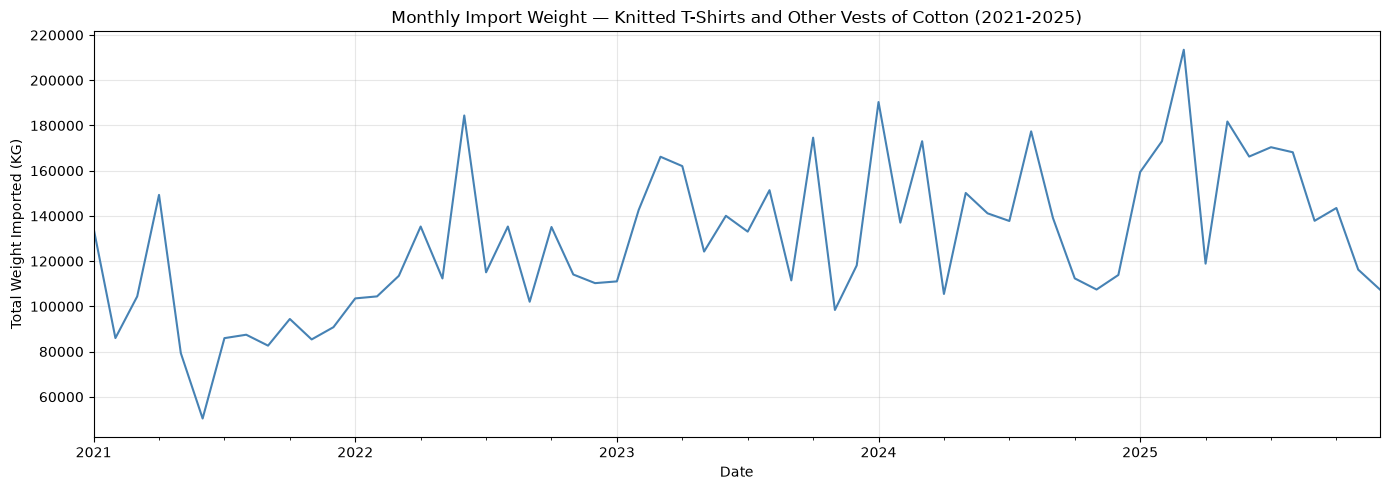

In [36]:
# Visualization 1 
monthly_trend = bh_imp_commodity.groupby(bh_imp_commodity['Import_Date'].dt.to_period('M'))['Import Weight (KG)'].sum()

plt.figure(figsize=(14, 5))
monthly_trend.plot(kind='line', color='steelblue')
plt.title('Monthly Import Weight — Knitted T-Shirts and Other Vests of Cotton (2021-2025)')
plt.xlabel('Date')
plt.ylabel('Total Weight Imported (KG)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Scratch/trend_chart.png', dpi=150, bbox_inches='tight')
plt.show()

**Visualization 1 Interpretation:**
> This chart displays the monthly import weight of Knitted T-Shirts from 2021 to 2025. There is some fluctuations at the beggining of the years as in 2021-2022 it was fluctuating within the range of 80,000-140,000 KG until it has peaked in 2024-2025 with over 200,000 KG, The data also indicates repeated seasonal rises and declines within each year, indicating continuous demand cycles rather than consistent.

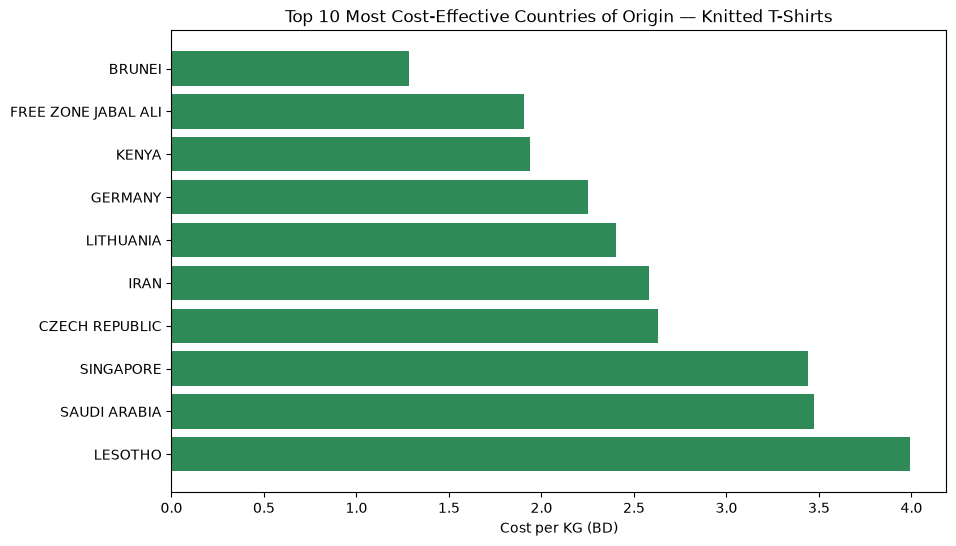

In [39]:
# Visualization 2
top_10_cheapest = bh_imp_commodity_grouped.sort_values('cost_per_kg').head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10_cheapest.index, top_10_cheapest['cost_per_kg'], color='seagreen')
plt.xlabel('Cost per KG (BD)')
plt.title('Top 10 Most Cost-Effective Countries of Origin — Knitted T-Shirts')
plt.gca().invert_yaxis()
plt.savefig('../Scratch/cost_chart.png', dpi=150, bbox_inches='tight')
plt.show()

**Visualization 2 Interpretation:**
> This chart shows the top 10 most cost-effective countries of origin by cost per kilogram (BD), Brunei set to be the lowest in cost per kg, followed closely by Free Zone Jabal Ali and Kenya, While Lesotho is the most expensive among the top 10 category. This immediately supports the problem statement: a company might select Brunei or Kenya as primary suppliers in a direct-import strategy to reduce buying expenses.

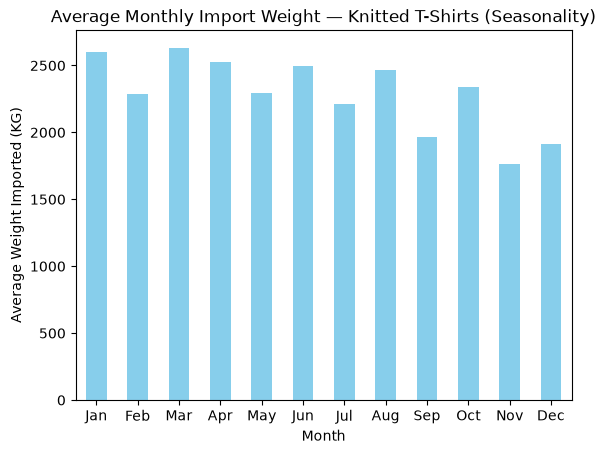

In [38]:
# Extract month name/number for seasonal grouping (ignoring year)
bh_imp_commodity['Month_Num'] = bh_imp_commodity['Import_Date'].dt.month

seasonal_avg = bh_imp_commodity.groupby('Month_Num')['Import Weight (KG)'].mean()

# Map month numbers to names for readable labels
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal_avg.index = month_names

seasonal_avg.plot(kind='bar', title='Average Monthly Import Weight — Knitted T-Shirts (Seasonality)', color='skyblue');
plt.ylabel('Average Weight Imported (KG)')
plt.xlabel('Month')
plt.xticks(rotation=0);
plt.savefig('../Scratch/seasonality_chart.png', dpi=150, bbox_inches='tight')
plt.show()

**Visualization 3 Interpretation:**
> This Chart shows the average of the import weight for each calender month, identifying seasonal patterns. The demand is highly increased in range of Jan - Aug as it peaks in March. as the demand slows during Q4 this directly supports the seasonal fluctuation.

---
## 5. Summary of Findings & Actionable Recommendations
*(Guidelines: Connect individual observations into a cohesive narrative that guides the target non-technical audience toward data-driven actions.)*

### 5.1 Key Insights (Summary of Findings)
*(Use bullet points to highlight the core truths revealed by your analysis)*
- Import volume for Knitted T-Shirts has grown noticeably since 2021, rising from roughly 
  80,000-140,000 KG per month to peaks exceeding 200,000 KG by 2024-2025.
- The data shows recurring seasonal spikes and dips within each year, rather than steady, 
  flat import levels — indicating predictable demand cycles rather than random fluctuation.
- Cost per kilogram varies substantially by country of origin — over 3x difference between 
  the cheapest and most expensive reliable suppliers (10+ transactions).
- Brunei, Free Zone Jabal Ali, and Kenya consistently offer the lowest cost per KG among 
  countries with meaningful transaction volume.

### 5.2 Actionable Recommendations
*(Translate your data into clear choices or recommendations for your stakeholder based directly on the problem statement)*
- Prioritize Brunei and Kenya as primary direct-import partners to meaningfully reduce 
  per-unit procurement costs compared to current distributor pricing.
- Time larger bulk orders ahead of the seasonal demand peaks identified in the trend 
  analysis, to avoid supply shortages during high-demand periods.
- Diversify sourcing across 2-3 of the top cost-effective countries (e.g. Brunei, Free Zone 
  Jabal Ali, Kenya) rather than relying on a single supplier, to reduce dependency risk.
- Re-evaluate supplier cost rankings periodically, since exchange rates and trade conditions 
  can shift which countries remain most cost-effective over time.

### 5.3 Limitations & Areas for Further Research
- Cost-per-KG does not account for shipping, customs, or lead-time differences between 
  countries, which would affect the true landed cost for the business.
- The dataset's Month column used inconsistent formats across years, which required 
  standardization before building a reliable date field.
- A small number of rows (13 out of ~1.6M) had missing Commodity/UM values and were dropped; 
  this had minimal impact given the dataset's size.
- Further research could incorporate shipping cost data or minimum order quantities per 
  country to refine the direct-import recommendation.

## 6. Data Dictionary & References

### 6.1 Data Dictionary
| Feature / Column | Data Type | Source | Description |
| :--- | :--- | :--- | :--- |
| Year | int64 | Original | Year of the import record. |
| Month | string | Original | Month of the import. |
| Commodity No | string | Original | Commodity identification code. |
| Commodity | string | Original | Name of the imported commodity. |
| UN code | string | Original | United Nations commodity code. |
| Country Name | string | Original | Country exporting the commodity. |
| Import Value (BD) | float64 | Original | Import value in Bahraini Dinar (BD). |
| Import Value (USA $) | float64 | Original | Import value in US Dollars (USD). |
| Import Weight (KG) | float64 | Original | Total import weight in kilograms. |
| Import Quantity | float64 | Original | Quantity of imported goods. |
| UM | string | Original | Unit of measurement. |
| Import_Date | datetime64 | Engineered | Date created by combining the Year and Month columns. |


### 6.2 References & Sources
* *Source 1:* https://www.data.gov.bh/explore/dataset/05-import-2021/table/?sort=-n
* *Source 2:* https://www.data.gov.bh/explore/dataset/04-import-2022/table/
* *Source 3:* https://www.data.gov.bh/explore/dataset/01-import-non-oil-classified-by-commodity-and-country-for-2023/table/?disjunctive.month&disjunctive.country_name
* *Source 4:* https://www.data.gov.bh/explore/dataset/import-2024/table/?disjunctive.month&sort=-n
* *Source 5:* https://www.data.gov.bh/explore/dataset/import-1-2025/table/?disjunctive.month&sort=year
* *Source 6:* https://www.foreign-trade.com/importers.htm